In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Supplemental_Table_Metagenomics.txt", sep="\t")

processed = data[data["total_reads"] >= 1_000_000].copy()

processed["sir_species_cpm"] = processed["reads_mapped_sir_species"] / processed["total_reads"] * 1_000_000
processed["ismA_species_cpm"] = processed["reads_mapped_ismA_species"] / processed["total_reads"] * 1_000_000
processed["ismA_gene_cpm"] = processed["reads_mapped_ismA_gene"] / processed["total_reads"] * 1_000_000
processed["sir_gene_cpm"] = processed["reads_mapped_sir_gene"] / processed["total_reads"] * 1_000_000

processed["ismA_Encoder"] = np.where(processed["ismA_gene_cpm"] >= 1, "Encoder", "Non-Encoder")
processed["sir_Encoder"] = np.where(processed["sir_gene_cpm"] >= 1, "Encoder", "Non-Encoder")


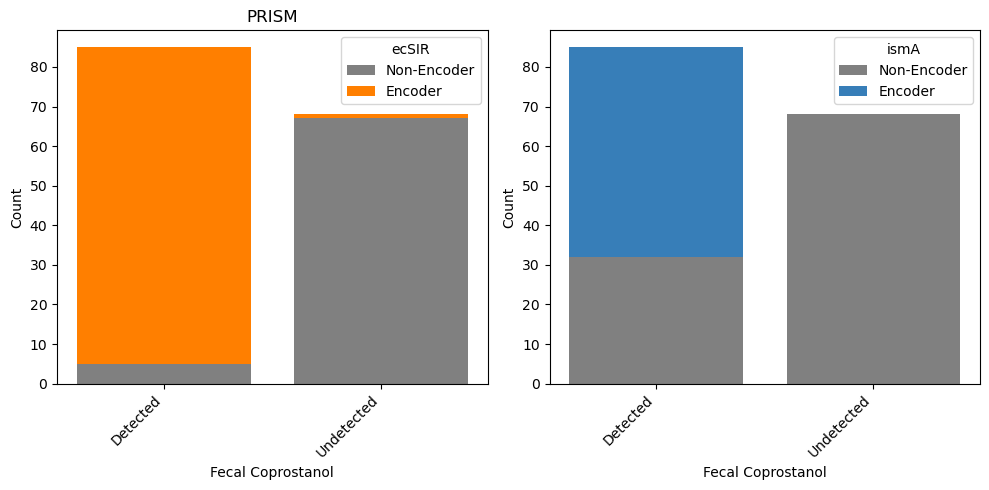

In [3]:
# PRISM
PRISM_area_threshold = 1e6

sir_summary_prism = (
    processed
    # Create the "Converter" vs "Non-Converter" column
    .assign(Converter=lambda df: np.where(df["area_coprostanol"] > PRISM_area_threshold, 
                                          "Converter", "Non-Converter"))
    .query("Study == 'PRISM'")
    # Group by Converter and sir_Encoder, and count
    .groupby(["Converter", "sir_Encoder"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

sir_summary_prism["Percentage"] = (
    sir_summary_prism.groupby("Converter")["Count"]
    .transform(lambda x: x / x.sum() * 100)
)

sir_summary_prism["Converter"] = sir_summary_prism["Converter"].map({
    "Converter": "Detected",
    "Non-Converter": "Undetected"
})

sir_summary_prism["sir_Encoder"] = pd.Categorical(
    sir_summary_prism["sir_Encoder"], 
    categories=["Non-Encoder", "Encoder"],
    ordered=True
)


ismA_summary_prism = (
    processed
    .assign(Converter=lambda df: np.where(df["area_coprostanol"] > PRISM_area_threshold, 
                                          "Converter", "Non-Converter"))
    .query("Study == 'PRISM'")
    .groupby(["Converter", "ismA_Encoder"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
)

ismA_summary_prism["Percentage"] = (
    ismA_summary_prism.groupby("Converter")["Count"]
    .transform(lambda x: x / x.sum() * 100)
)

# Factor/label adjustments
ismA_summary_prism["Converter"] = ismA_summary_prism["Converter"].map({
    "Converter": "Detected",
    "Non-Converter": "Undetected"
})
ismA_summary_prism["ismA_Encoder"] = pd.Categorical(
    ismA_summary_prism["ismA_Encoder"], 
    categories=["Non-Encoder", "Encoder"],
    ordered=True
)

# -----------------------------------------------------
# 3. Create stacked bar plots side by side with matplotlib
# -----------------------------------------------------

# Colors for ecSIR and ismA encoders:
colors_sir = {
    "Non-Encoder": "gray",
    "Encoder": "#ff7f00"
}
colors_ismA = {
    "Non-Encoder": "gray",
    "Encoder": "#377eb8"
}

# Pivot each summary so columns become encoder categories
sir_pivot = sir_summary_prism.pivot(index="Converter", 
                                    columns="sir_Encoder", 
                                    values="Count").fillna(0)
ismA_pivot = ismA_summary_prism.pivot(index="Converter", 
                                      columns="ismA_Encoder", 
                                      values="Count").fillna(0)

# Create subplots for side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------------------------
# 4. Plot for sir_summary_prism
# ---------------------------
ax1 = axes[0]
bottom = np.zeros(len(sir_pivot))
x_positions = np.arange(len(sir_pivot.index))  # numeric positions for x-axis

# Ensure we plot in the order: Non-Encoder, then Encoder
for encoder_type in sir_pivot.columns:
    ax1.bar(
        x_positions,
        sir_pivot[encoder_type],
        bottom=bottom,
        label=encoder_type,
        color=colors_sir[encoder_type]
    )
    bottom += sir_pivot[encoder_type]

ax1.set_title("PRISM")  
ax1.set_xticks(x_positions)
ax1.set_xticklabels(sir_pivot.index, rotation=45, ha="right")
ax1.set_xlabel("Fecal Coprostanol")
ax1.set_ylabel("Count")
ax1.legend(title="ecSIR", loc="best")

# ---------------------------
# 5. Plot for ismA_summary_prism
# ---------------------------
ax2 = axes[1]
bottom = np.zeros(len(ismA_pivot))
x_positions = np.arange(len(ismA_pivot.index))

for encoder_type in ismA_pivot.columns:
    ax2.bar(
        x_positions,
        ismA_pivot[encoder_type],
        bottom=bottom,
        label=encoder_type,
        color=colors_ismA[encoder_type]
    )
    bottom += ismA_pivot[encoder_type]

ax2.set_xticks(x_positions)
ax2.set_xticklabels(ismA_pivot.index, rotation=45, ha="right")
ax2.set_xlabel("Fecal Coprostanol")
ax2.set_ylabel("Count")
ax2.legend(title="ismA", loc="best")

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def plot_study_metabolite(
    ax,
    data,
    study,
    y_col,
    study_label="",
    y_label=""
):
    """
    Draws a violin + box + jitter for a single study × metabolite combination
    on the specified Axes object 'ax'.
    
    The plot will contain 4 groups on the x-axis:
        1) sir_Encoder=Non-Encoder
        2) sir_Encoder=Encoder
        3) ismA_Encoder=Non-Encoder
        4) ismA_Encoder=Encoder

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The Axes to draw on.
    data : pd.DataFrame
        Full dataset containing columns: 'Study', 'sir_Encoder', 'ismA_Encoder', etc.
    study : str
        The study name to filter on (e.g. 'HMP2', 'PRISM', 'PROTECT').
    y_col : str
        The name of the metabolite column, e.g. 'area_cholesterol'.
    study_label : str
        Label to display as the subplot title (usually the study name).
    y_label : str
        Y-axis label (e.g. 'Stool Cholesterol (log10 peak area)').
    """
    df = data.loc[data["Study"] == study].copy()
    df["sir_Encoder"] = pd.Categorical(df["sir_Encoder"], 
                                       categories=["Non-Encoder", "Encoder"],
                                       ordered=True)
    df["ismA_Encoder"] = pd.Categorical(df["ismA_Encoder"],
                                        categories=["Non-Encoder", "Encoder"],
                                        ordered=True)

    df["y_log"] = np.log10(df[y_col] + 1)

    category_map = [
        ("sir_Encoder", "Non-Encoder"),
        ("sir_Encoder", "Encoder"),
        ("ismA_Encoder", "Non-Encoder"),
        ("ismA_Encoder", "Encoder")
    ]

    fill_colors = {
        ("sir_Encoder", "Non-Encoder"): "gray",
        ("sir_Encoder", "Encoder"): "#ff7f00",  # orange
        ("ismA_Encoder", "Non-Encoder"): "gray",
        ("ismA_Encoder", "Encoder"): "#377eb8"  # blue
    }

    # Extract arrays for each group
    group_data = []
    for (enc_col, enc_val) in category_map:
        vals = df.loc[df[enc_col] == enc_val, "y_log"].values
        group_data.append(vals)

    # Violin plot
    vp = ax.violinplot(
        dataset=group_data,
        positions=range(len(group_data)),  # [0,1,2,3]
        widths=0.8,
        showmeans=False,
        showextrema=False,
        showmedians=False
    )
    for i, body in enumerate(vp['bodies']):
        #body.set_facecolor(fill_colors[category_map[i]])
        body.set_facecolor("none")
        body.set_edgecolor('black')
        body.set_linewidth(0.5)
        body.set_alpha(1.0)

    # Box plot
    bp = ax.boxplot(
        group_data,
        positions=range(len(group_data)),
        widths=0.3,
        patch_artist=True,
        showfliers=False  # hide outliers
    )
    for i, box in enumerate(bp['boxes']):
        #box.set_facecolor(fill_colors[category_map[i]])
        box.set_facecolor("none")
        box.set_edgecolor('black')
        box.set_linewidth(0.5)
        box.set_alpha(1)
    for whisker in bp['whiskers']:
        whisker.set_linewidth(1)
        whisker.set_color('black')
    for cap in bp['caps']:
        cap.set_linewidth(0.5)
        cap.set_color('black')
    for median in bp['medians']:
        median.set_linewidth(1)
        median.set_color('black')

    np.random.seed(42)
    jitter_width = 0.6
    dot_colors = {
    ("sir_Encoder", "Non-Encoder"): "darkgray",
    ("sir_Encoder", "Encoder"): "#ff7f00",
    ("ismA_Encoder", "Non-Encoder"): "darkgray",
    ("ismA_Encoder", "Encoder"): "#377eb8" 
    }
    
    for i, gd in enumerate(group_data):
        x_center = i
        x_jittered = x_center + (np.random.rand(len(gd)) - 0.5) * jitter_width
    
        # Grab the right color from the dictionary
        c = dot_colors[category_map[i]]
    
        ax.scatter(
            x_jittered, gd,
            marker='o',
            s=9,
            facecolors=c,
            edgecolors="none",
            alpha=0.6,
            zorder=3  # keep them on top
        )

    xlabels = [
        "sir(-)", "sir(+)",
        "ismA(-)", "ismA(+)" 
    ]
    ax.set_xticks(range(len(group_data)))
    ax.set_xticklabels(xlabels, rotation=45, ha="center")

    # Title, axis labels
    ax.set_title(study_label, fontweight="bold")
    ax.set_ylabel(y_label)
    test_type = "less"
    if y_col == "area_cholesterol":
        test_type = "greater"
    # ------------------------------------
# 1) Mann-Whitney for sir: 0 vs 1
# ------------------------------------
    sir_non_enc = group_data[0]
    sir_enc     = group_data[1]
    stat_sir, p_sir = mannwhitneyu(sir_non_enc, sir_enc, alternative=test_type)

# We'll place a bracket spanning [x=0, x=1] above the maximum of these two groups
    y_max_sir = max(sir_non_enc.max(), sir_enc.max())
    line_height_sir = y_max_sir + 0.2  # adjust gap as needed

# Draw bracket
    ax.plot([0, 0, 1, 1], [line_height_sir, line_height_sir+0.05, 
                       line_height_sir+0.05, line_height_sir], 
             lw=1.0, color="black")

# Add text with the p-value above the bracket
    ax.text(0.5, line_height_sir+0.07, 
            f"p={p_sir:.2g}",  # 3 significant figures
            ha="center", va="bottom", fontsize=12)


    ismA_non_enc = group_data[2]
    ismA_enc     = group_data[3]
    
    stat_ismA, p_ismA = mannwhitneyu(ismA_non_enc, ismA_enc, alternative=test_type)

    y_max_ismA = max(ismA_non_enc.max(), ismA_enc.max())
    line_height_ismA = y_max_ismA + 0.2

    ax.plot([2, 2, 3, 3], [line_height_ismA, line_height_ismA+0.05, 
                       line_height_ismA+0.05, line_height_ismA], 
         lw=1.0, color="black")

    ax.text(2.5, line_height_ismA+0.07, 
            f"p={p_ismA:.2g}",
            ha="center", va="bottom", fontsize=12)


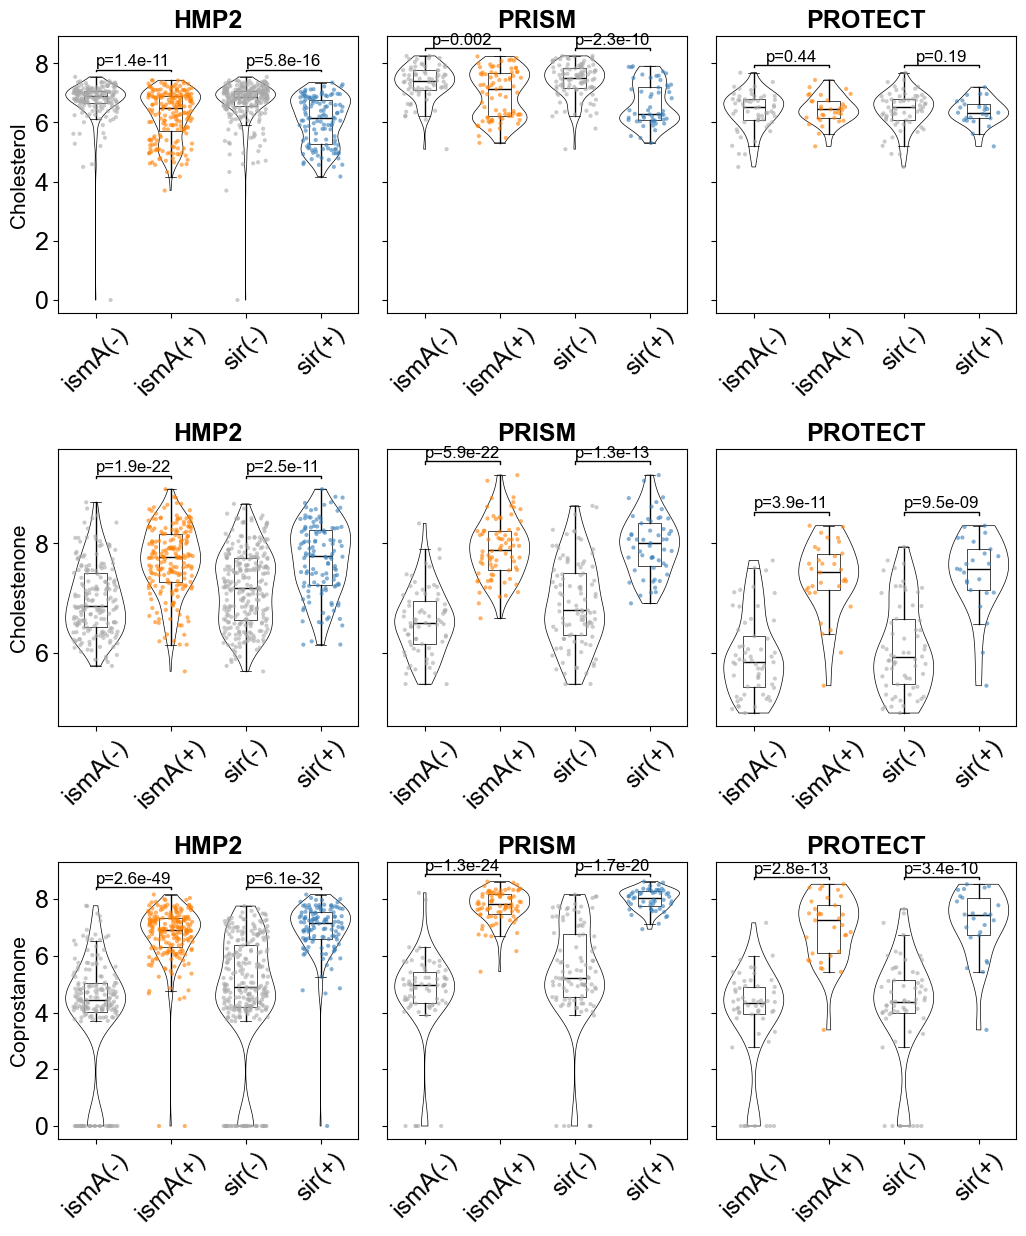

In [37]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 15,
    'axes.titlesize': 18, 
    'axes.labelsize': 15, 
    'xtick.labelsize': 15,  
    'ytick.labelsize': 15,
    'legend.fontsize': 15 
})

processed["sir_Encoder"] = pd.Categorical(
    processed["sir_Encoder"], categories=["Non-Encoder", "Encoder"], ordered=True
)
processed["ismA_Encoder"] = pd.Categorical(
    processed["ismA_Encoder"], categories=["Non-Encoder", "Encoder"], ordered=True
)

# The three metabolites
metabolites = [
    ("area_cholesterol",   "Cholesterol"),
    ("area_cholestenone",  "Cholestenone"),
    ("area_coprostanol",   "Coprostanone")
]

study_list = ["HMP2", "PRISM", "PROTECT"]

inch = 89 * 3 / 25.4
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(inch, inch*1.2), sharey='row')

for row_idx, (met_col, met_label) in enumerate(metabolites):
    for col_idx, study_name in enumerate(study_list):
        ax = axes[row_idx, col_idx]
        plot_study_metabolite(
            ax=ax,
            data=processed,
            study=study_name,
            y_col=met_col,
            study_label=study_name, 
            y_label=(met_label if col_idx == 0 else "")
        ) 
        
plt.tight_layout()

plt.savefig("Fig_Metabolite.svg", format="svg")  
plt.show()
